Dataset columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing values by column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0

Target column: Outcome
Class counts:
Outcome
0    500
1    268

Comparison on the same test set:
           Accuracy  Precision  Recall  F1-score Confusion matrix [TN, FP; FN, TP]
Threshold                                                                         
0.5          0.7143     0.6087  0.5185    0.5600              [[82, 18], [26, 28]]
0.3          0.7403     0.5946  0.8148    0.6875              [[70, 30], [10, 44]]

Test predictions changed at threshold 0.3: 28


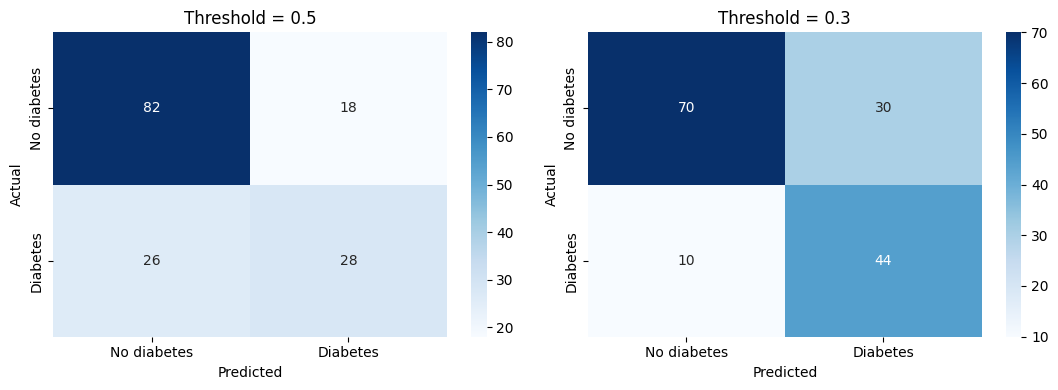

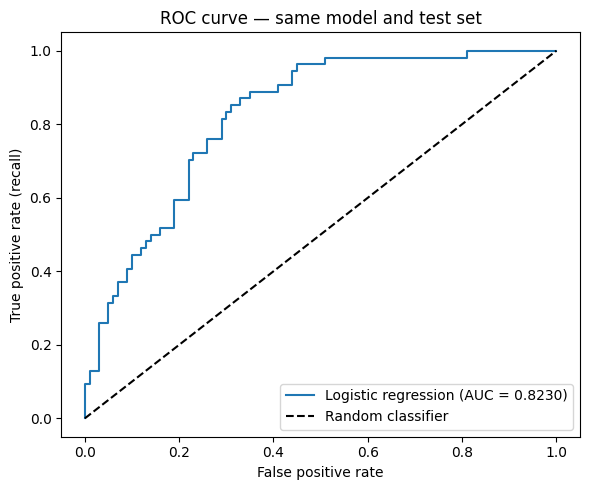

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

CSV_PATH = "/content/archive.zip"
df = pd.read_csv(CSV_PATH)

# Inspect the dataset before training
print("Dataset columns:", df.columns.tolist())
print("\nMissing values by column:")
print(df.isna().sum().to_string())

if "Outcome" in df.columns:
    target = "Outcome"
else:
    candidates = [
        col for col in df.columns
        if any(word in col.lower() for word in ("diabetes", "diabetic", "outcome"))
        and df[col].dropna().nunique() == 2
    ]
    if len(candidates) != 1:
        raise ValueError(
            "Could not identify one binary diabetes label. "
            f"Inspect these columns and set target manually: {df.columns.tolist()}"
        )
    target = candidates[0]

print(f"\nTarget column: {target}")
print("Class counts:")
print(df[target].value_counts(dropna=False).to_string())

if df[target].isna().any() or set(df[target].unique()) != {0, 1}:
    raise ValueError(
        "This code expects a complete binary target coded 0 = no diabetes, "
        "1 = diabetes. Check the target values before continuing."
    )

X = df.drop(columns=target).apply(pd.to_numeric, errors="raise")
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# The imputer and scaler are fitted on training records only.
model = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)
model.fit(X_train, y_train)

# Train once; reuse these exact probabilities and test records.
probabilities = model.predict_proba(X_test)[:, 1]
predictions = {
    0.5: (probabilities >= 0.5).astype(int),
    0.3: (probabilities >= 0.3).astype(int),
}

rows = []
matrices = {}
for threshold, predicted in predictions.items():
    cm = confusion_matrix(y_test, predicted, labels=[0, 1])
    matrices[threshold] = cm
    rows.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, predicted),
        "Precision": precision_score(y_test, predicted, zero_division=0),
        "Recall": recall_score(y_test, predicted, zero_division=0),
        "F1-score": f1_score(y_test, predicted, zero_division=0),
        "Confusion matrix [TN, FP; FN, TP]": cm.tolist(),
    })

comparison = pd.DataFrame(rows).set_index("Threshold")
print("\nComparison on the same test set:")
print(comparison.to_string(float_format=lambda value: f"{value:.4f}"))

changed = np.count_nonzero(predictions[0.5] != predictions[0.3])
print(f"\nTest predictions changed at threshold 0.3: {changed}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, threshold in zip(axes, predictions):
    sns.heatmap(
        matrices[threshold], annot=True, fmt="d", cmap="Blues",
        xticklabels=["No diabetes", "Diabetes"],
        yticklabels=["No diabetes", "Diabetes"],
        ax=ax
    )
    ax.set(title=f"Threshold = {threshold}", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, probabilities)
auc = roc_auc_score(y_test, probabilities)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic regression (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (recall)")
plt.title("ROC curve — same model and test set")
plt.legend()
plt.tight_layout()
plt.show()